<a href="https://colab.research.google.com/github/amartinsmg/classification-of-medical-images-using-cnn/blob/main/notebooks/analyses/03_class_weight.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%cd /content
!git clone https://github.com/amartinsmg/classification-of-medical-images-using-cnn.git
%cd /content/classification-of-medical-images-using-cnn

/content
Cloning into 'classification-of-medical-images-using-cnn'...
remote: Enumerating objects: 1026, done.
remote: Counting objects: 100% (414/414), done.
remote: Compressing objects: 100% (286/286), done.
remote: Total 1026 (delta 184), reused 321 (delta 123), pack-reused 612 (from 1)
Receiving objects: 100% (1026/1026), 8.78 MiB | 26.21 MiB/s, done.
Resolving deltas: 100% (510/510), done.
/content/classification-of-medical-images-using-cnn


In [2]:
from google.colab import drive

drive.mount("/content/drive")

BASE_PATH = "/content/drive/MyDrive/classification-of-medical-images-using-cnn/"

Mounted at /content/drive


In [3]:
experiment_names = ["efficientnet-no-data-aug", "efficientnet-class-weight",
                  "densenet-no-data-aug", "densenet-class-weight",
                  "resnet-no-data-aug", "resnet-class-weight"]
COMPARISON_PATH = "comparisons/03-class-weight"
RESULT_PATH = BASE_PATH + "results"
SAVE_DIR = BASE_PATH + COMPARISON_PATH

In [4]:
from src.analyses import load_experiments

experiments = load_experiments(RESULT_PATH, experiment_names)

In [5]:
from src.analyses import metrics_table
from IPython.display import display

metrics = metrics_table(experiments)
display(metrics)

,accuracy-mean,accuracy-std,precision-mean,precision-std,recall-mean,recall-std,f1-score-mean,f1-score-std,specificity-mean,specificity-std,auc-roc-mean,auc-roc-std
experiment,,,,,,,,,,,,
efficientnet-no-data-aug,0.796474,0.030095,0.756865,0.028928,0.996581,0.003198,0.859976,0.017490,0.462963,0.085494,0.968920,0.002772
efficientnet-class-weight,0.845085,0.004206,0.806926,0.006896,0.988889,0.004835,0.888649,0.002221,0.605413,0.019218,0.969958,0.001839
densenet-no-data-aug,0.819979,0.056270,0.788886,0.064417,0.985470,0.015432,0.874262,0.033387,0.544160,0.174756,0.962950,0.003478
densenet-class-weight,0.844017,0.042042,0.823509,0.069227,0.969231,0.032636,0.887430,0.024917,0.635328,0.165745,0.960771,0.003623
resnet-no-data-aug,0.808226,0.018704,0.768948,0.019748,0.992308,0.004187,0.866276,0.010908,0.501425,0.056730,0.963535,0.003811
resnet-class-weight,0.831197,0.053908,0.818086,0.086537,0.961538,0.042028,0.879198,0.030881,0.613960,0.211681,0.960545,0.005001


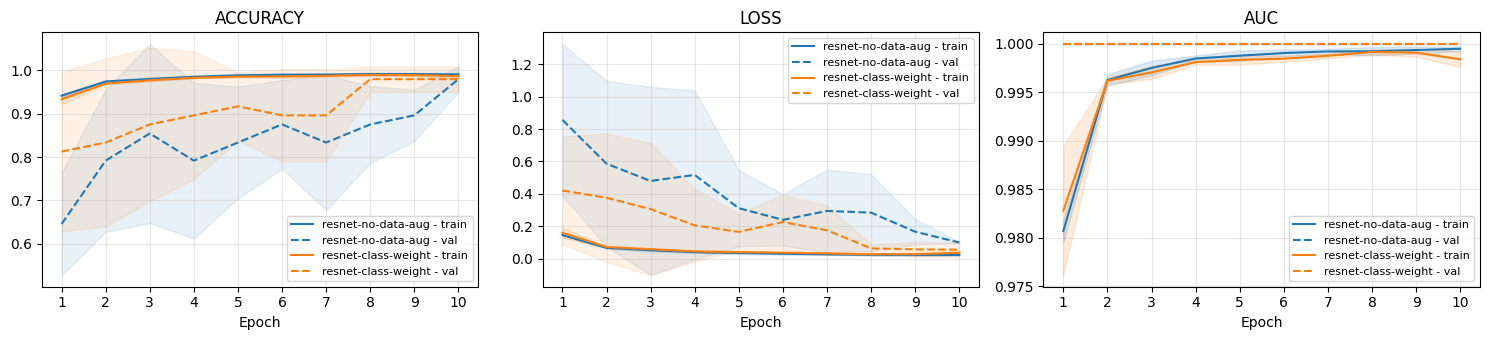

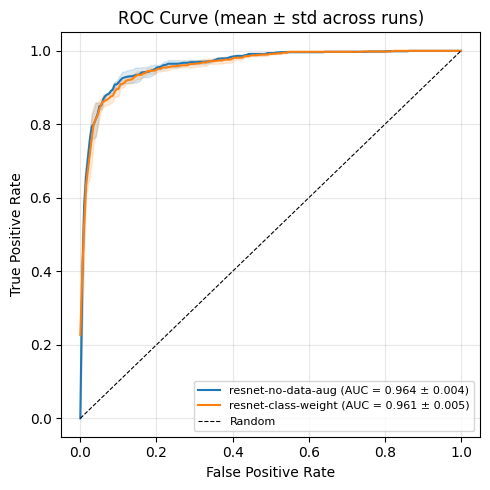

In [6]:
from src.analyses import plot_training_history
from src.analyses import plot_roc_curves
import matplotlib.pyplot as plt

resnet_exps = [exp for exp in experiments if exp.get("name").startswith("resnet")]

fig_history = plot_training_history(resnet_exps)
fig_roc = plot_roc_curves(resnet_exps)

plt.show()

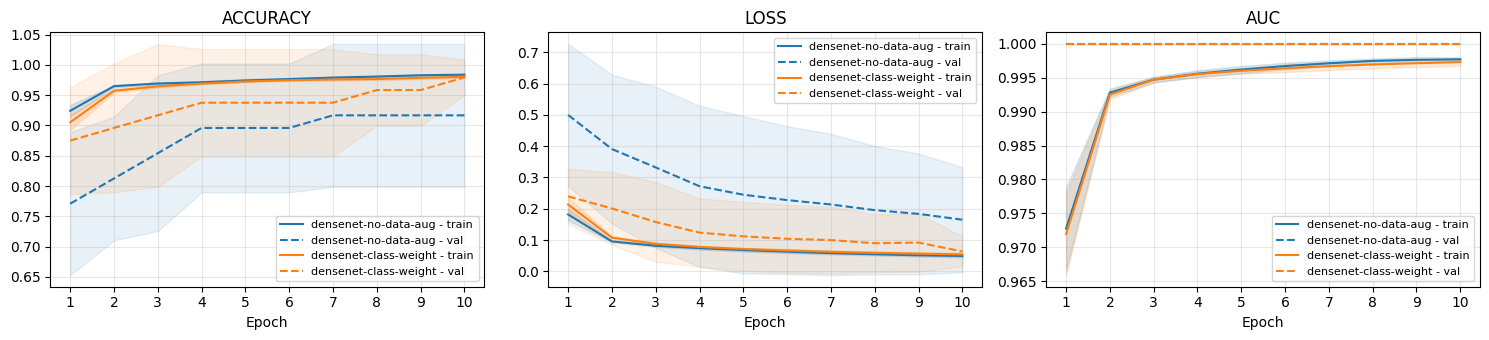

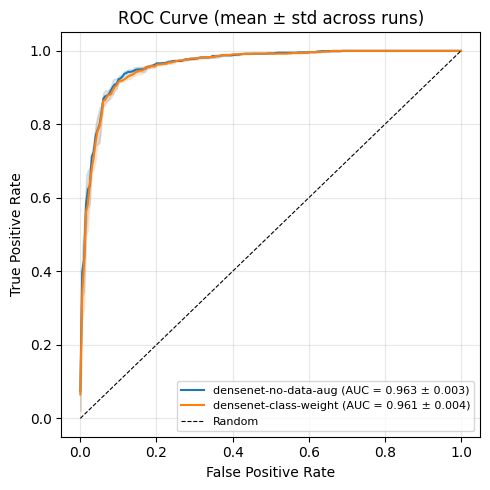

In [7]:
densenet_exps = [exp for exp in experiments if exp.get("name").startswith("densenet")]

fig = plot_training_history(densenet_exps)
fig = plot_roc_curves(densenet_exps)

plt.show()

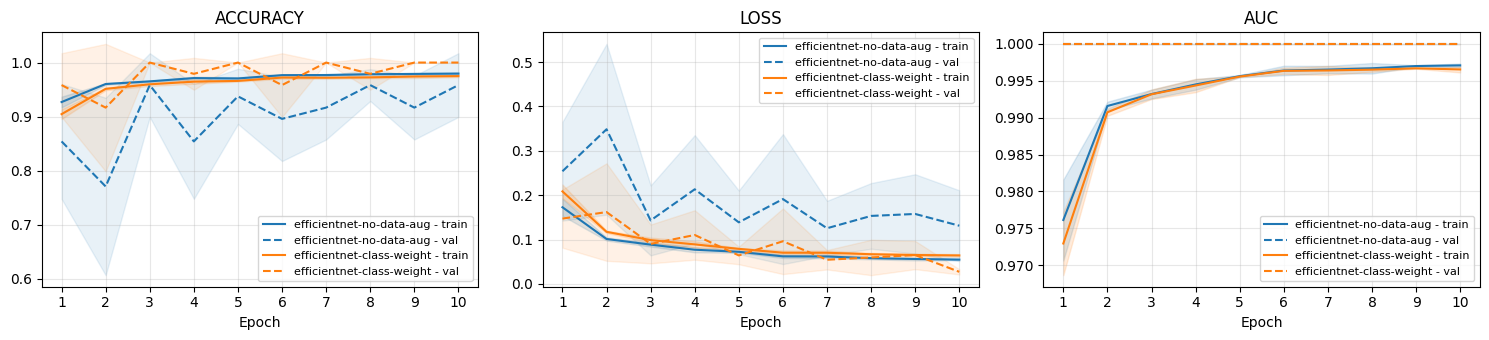

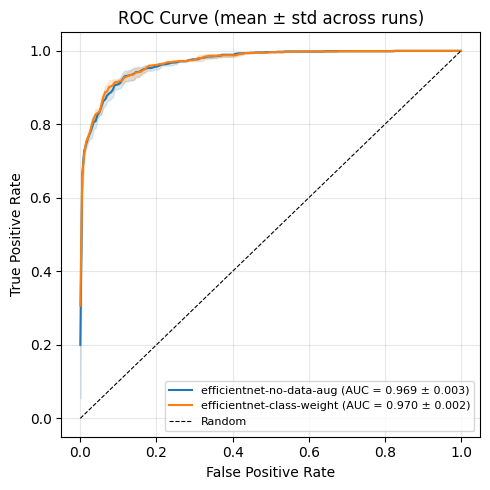

In [8]:
efficientnet_exps = [exp for exp in experiments if exp.get("name").startswith("efficientnet")]

fig = plot_training_history(efficientnet_exps)
fig = plot_roc_curves(efficientnet_exps)

plt.show()

In [9]:
from src.analyses import full_comparison

_ = full_comparison(
  base_result_dir=RESULT_PATH,
  experiment_names=experiment_names,
  show_plot=False,
  save_dir=SAVE_DIR,
  separe_archs=True
)


Results saved in /content/drive/MyDrive/classification-of-medical-images-using-cnn/comparisons/03-class-weight


Faz upload da tabela e dos gráficos das comparações para o DagsHub

In [12]:
%pip install -q dvc dagshub

import dagshub
from google.colab import userdata

dagshub.auth.add_app_token(token=userdata.get("DAGSHUB_TOKEN"))


dagshub.upload_files(
    "amartinsmg/classification-of-medical-images-using-cnn",
    local_path=SAVE_DIR,
    remote_path=COMPARISON_PATH,
)

Output()

Directory upload complete, uploaded 13 files to 
https://dagshub.com/amartinsmg/classification-of-medical-images-using-cnn/src/main/comparisons%2F03-class-weight